# Baseline 01: Data Landscape

**Question:** What data do we have?

This notebook explores the raw material before building any networks:
1. Dimensions & year coverage
2. Variable completeness
3. Pairwise overlap
4. Response distributions

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.loaders.import_gss import import_dataset
from src.loaders.clean_raw_data import clean_datasets, DataConfig
from src.analyzers.overlap_analyzer import calculate_overlap_matrix, plot_overlap_matrix

## 0. Load Data

In [2]:
raw_df, _ = import_dataset()
cleaned_df = clean_datasets()

Loading dataset from from cache...


Done! ✨
Loading dataset from from cache...


Done! ✨


## 1.1 Dimensions & Year Coverage

How many respondents, years, and variables do we have?

In [3]:
print("=== RAW DATASET ===")
print(f"Respondents (rows): {raw_df.shape[0]:,}")
print(f"Variables (columns): {raw_df.shape[1]}")
print(f"Years covered: {int(raw_df['YEAR'].min())} - {int(raw_df['YEAR'].max())}")
print(f"Unique years: {raw_df['YEAR'].nunique()}")
print()
print("=== CLEANED DATASET ===")
print(f"Respondents (rows): {cleaned_df.shape[0]:,}")
print(f"Variables (columns): {cleaned_df.shape[1]}")

# Exclude metadata columns
exclude = DataConfig.EXCLUDE_COLS
belief_vars = [c for c in cleaned_df.columns if c not in exclude]
print(f"Belief variables (excl. YEAR/BALLOT/ID): {len(belief_vars)}")

=== RAW DATASET ===
Respondents (rows): 72,390
Variables (columns): 166
Years covered: 1972 - 2022
Unique years: 34

=== CLEANED DATASET ===
Respondents (rows): 72,390
Variables (columns): 136
Belief variables (excl. YEAR/BALLOT/ID): 133


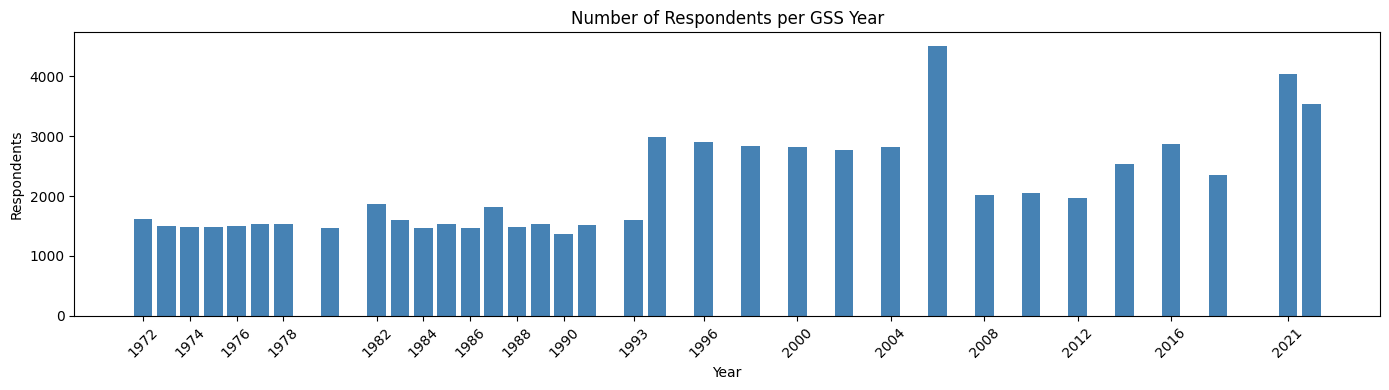

Min respondents/year: 1,372 (1990.0)
Max respondents/year: 4,510 (2006.0)
Mean respondents/year: 2,129


In [4]:
# Respondents per year
year_counts = cleaned_df['YEAR'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(year_counts.index, year_counts.values, color='steelblue')
ax.set_xlabel('Year')
ax.set_ylabel('Respondents')
ax.set_title('Number of Respondents per GSS Year')
ax.set_xticks(year_counts.index[::2])
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(f"Min respondents/year: {year_counts.min():,} ({year_counts.idxmin()})")
print(f"Max respondents/year: {year_counts.max():,} ({year_counts.idxmax()})")
print(f"Mean respondents/year: {year_counts.mean():,.0f}")

## 1.2 Variable Completeness

Which variables are available when? How much is missing?

In [5]:
# Overall missingness per variable
missing_pct = cleaned_df[belief_vars].isnull().mean().sort_values(ascending=False) * 100

print(f"Variables with <25% missing: {(missing_pct < 25).sum()}")
print(f"Variables with 25-50% missing: {((missing_pct >= 25) & (missing_pct < 50)).sum()}")
print(f"Variables with 50-75% missing: {((missing_pct >= 50) & (missing_pct < 75)).sum()}")
print(f"Variables with >75% missing: {(missing_pct >= 75).sum()}")
print()
print("Top 20 most-missing variables:")
print(missing_pct.head(20).to_string())

Variables with <25% missing: 18
Variables with 25-50% missing: 79
Variables with 50-75% missing: 32
Variables with >75% missing: 4

Top 20 most-missing variables:
MARHOMO                     89.700235
SPKMSLM                     84.069623
LIBMSLM                     84.058572
COLMSLM                     80.609200
NATENRGY                    74.178754
WOULDVOTELAST_DEMREP        73.065341
WOULDVOTELAST_NONCONFORM    68.316066
NATCITYY                    66.633513
NATRACEY                    65.901368
WRKWAYUP                    65.683105
AFFRMACT                    65.502141
NATSCI                      64.613897
NATSPACY                    64.025418
NATDRUGY                    64.022655
NATARMSY                    63.428650
NATENVIY                    63.231109
NATAIDY                     63.130267
NATCRIMY                    62.831883
NATHEALY                    62.744854
NATFAREY                    62.703412


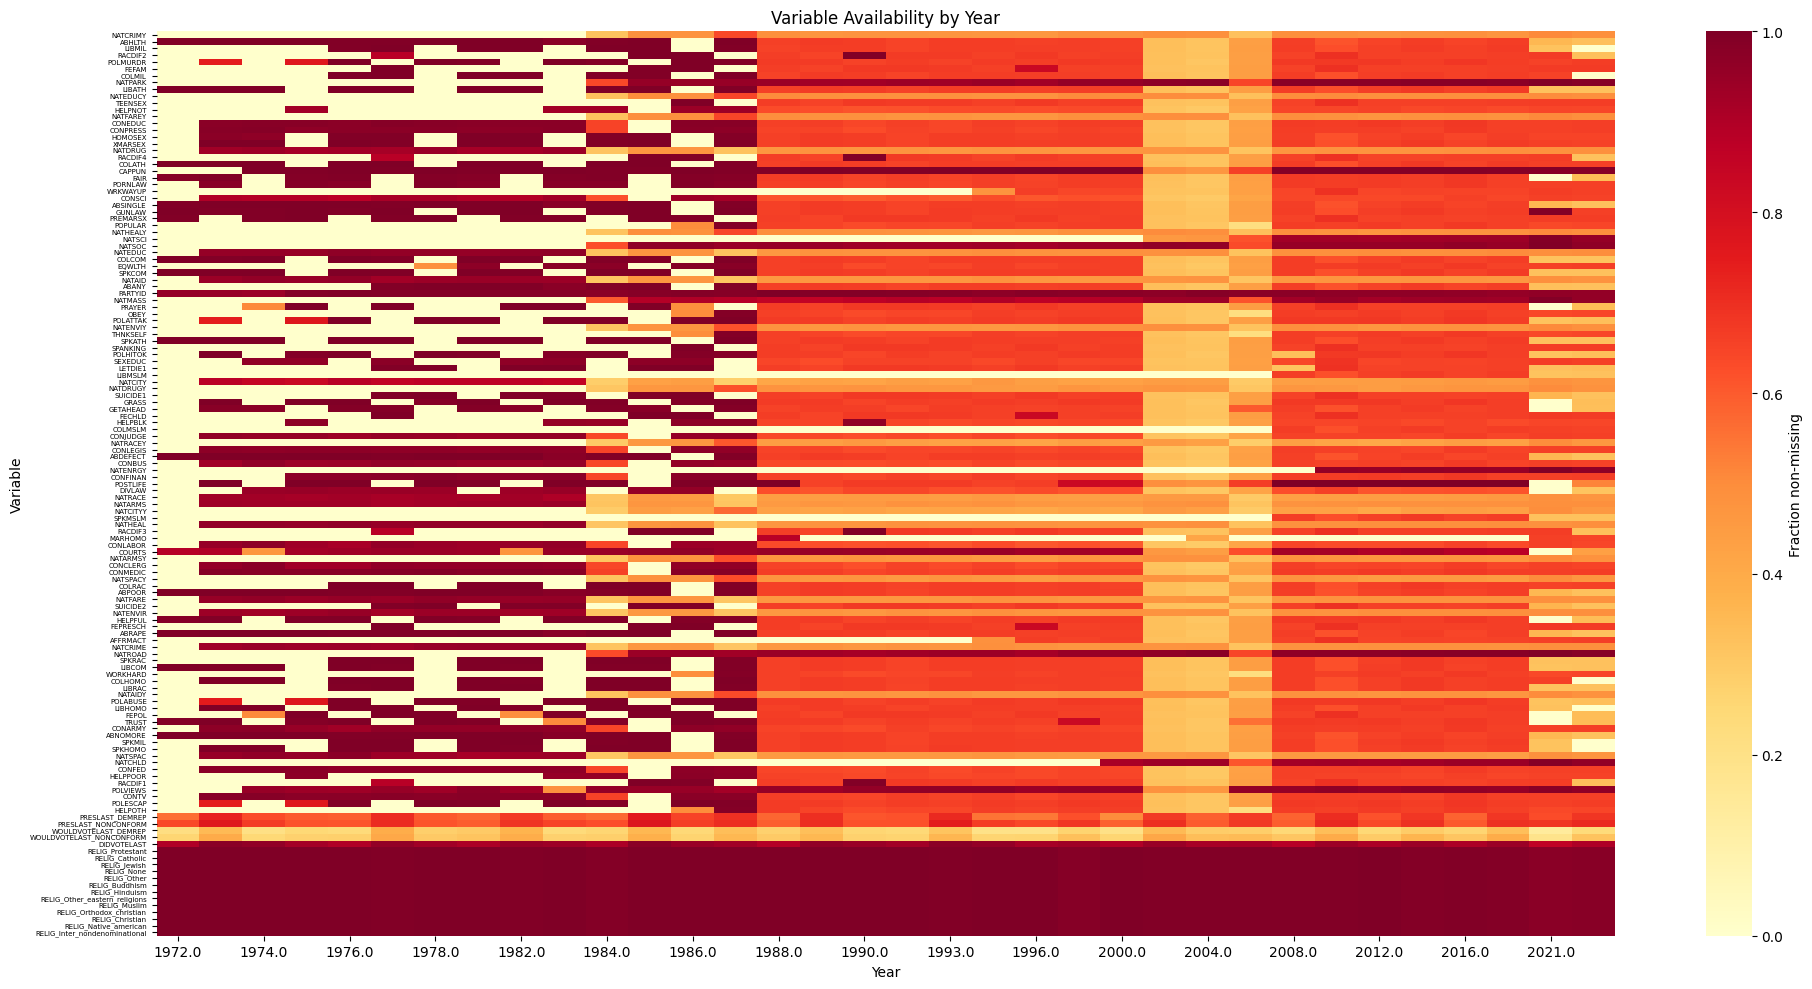

In [6]:
# Year-by-variable availability heatmap
years = sorted(cleaned_df['YEAR'].unique())
availability = pd.DataFrame(index=years, columns=belief_vars, dtype=float)

for year in years:
    year_data = cleaned_df[cleaned_df['YEAR'] == year][belief_vars]
    availability.loc[year] = year_data.notna().mean()

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(availability.astype(float).T, cmap='YlOrRd', ax=ax,
            xticklabels=2, yticklabels=True,
            cbar_kws={'label': 'Fraction non-missing'})
ax.set_xlabel('Year')
ax.set_ylabel('Variable')
ax.set_title('Variable Availability by Year')
ax.tick_params(axis='y', labelsize=5)
plt.tight_layout()
plt.show()

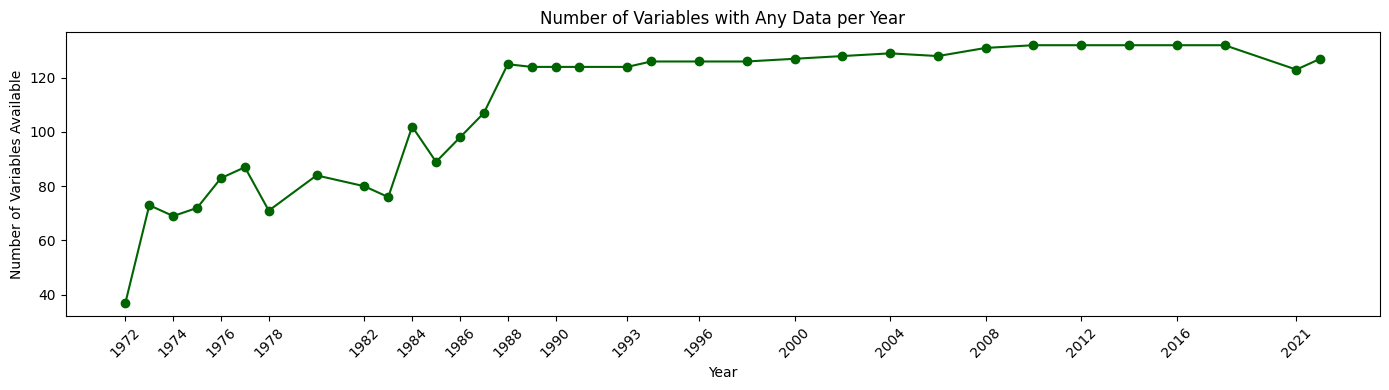

Early period (1972-1985): 77 vars on average
Late period (2010-2022): 130 vars on average


In [7]:
# Count how many variables are available (>0 responses) per year
vars_per_year = (availability > 0).sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(vars_per_year.index, vars_per_year.values, 'o-', color='darkgreen')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Variables Available')
ax.set_title('Number of Variables with Any Data per Year')
ax.set_xticks(vars_per_year.index[::2])
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(f"Early period (1972-1985): {vars_per_year.loc[1972:1985].mean():.0f} vars on average")
print(f"Late period (2010-2022): {vars_per_year.loc[2010:2022].mean():.0f} vars on average")

## 1.3 Pairwise Overlap

When two variables co-occur, how many respondents answered both?

In [8]:
# Calculate overlap on belief variables only
overlap_matrix = calculate_overlap_matrix(cleaned_df[belief_vars])

# Summary stats
# Get upper triangle values (excluding diagonal)
mask = np.triu(np.ones(overlap_matrix.shape, dtype=bool), k=1)
upper_vals = overlap_matrix.values[mask]

print(f"Pairwise overlap statistics (% of all respondents):")
print(f"  Min:    {np.nanmin(upper_vals):.1f}%")
print(f"  Median: {np.nanmedian(upper_vals):.1f}%")
print(f"  Mean:   {np.nanmean(upper_vals):.1f}%")
print(f"  Max:    {np.nanmax(upper_vals):.1f}%")
print(f"  Pairs with <10% overlap: {(upper_vals < 10).sum()}")
print(f"  Pairs with <5% overlap:  {(upper_vals < 5).sum()}")

Pairwise overlap statistics (% of all respondents):
  Min:    0.0%
  Median: 33.5%
  Mean:   35.8%
  Max:    99.4%
  Pairs with <10% overlap: 480
  Pairs with <5% overlap:  217


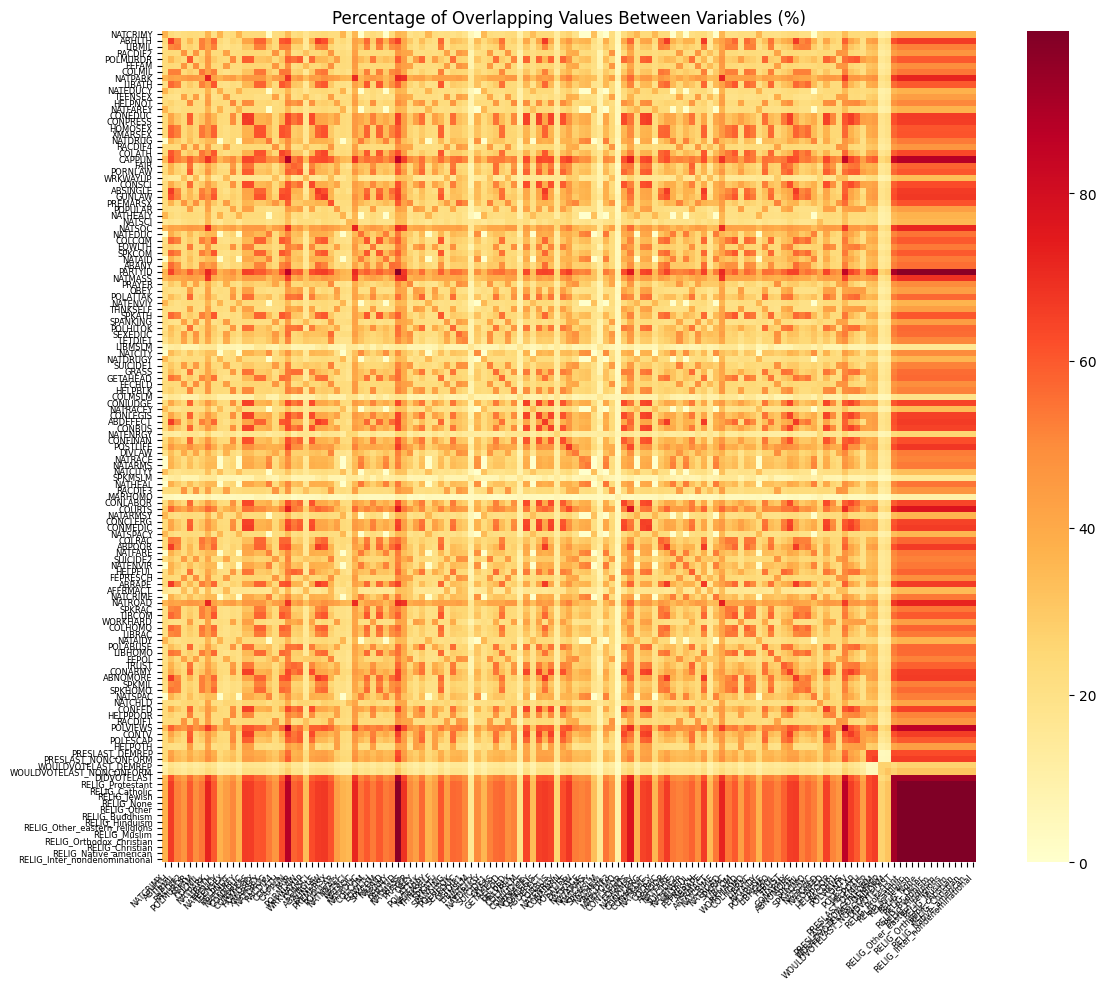

In [9]:
plot_overlap_matrix(overlap_matrix)

## 1.4 Response Distributions

What do the cleaned values look like? Are they symmetric around zero?

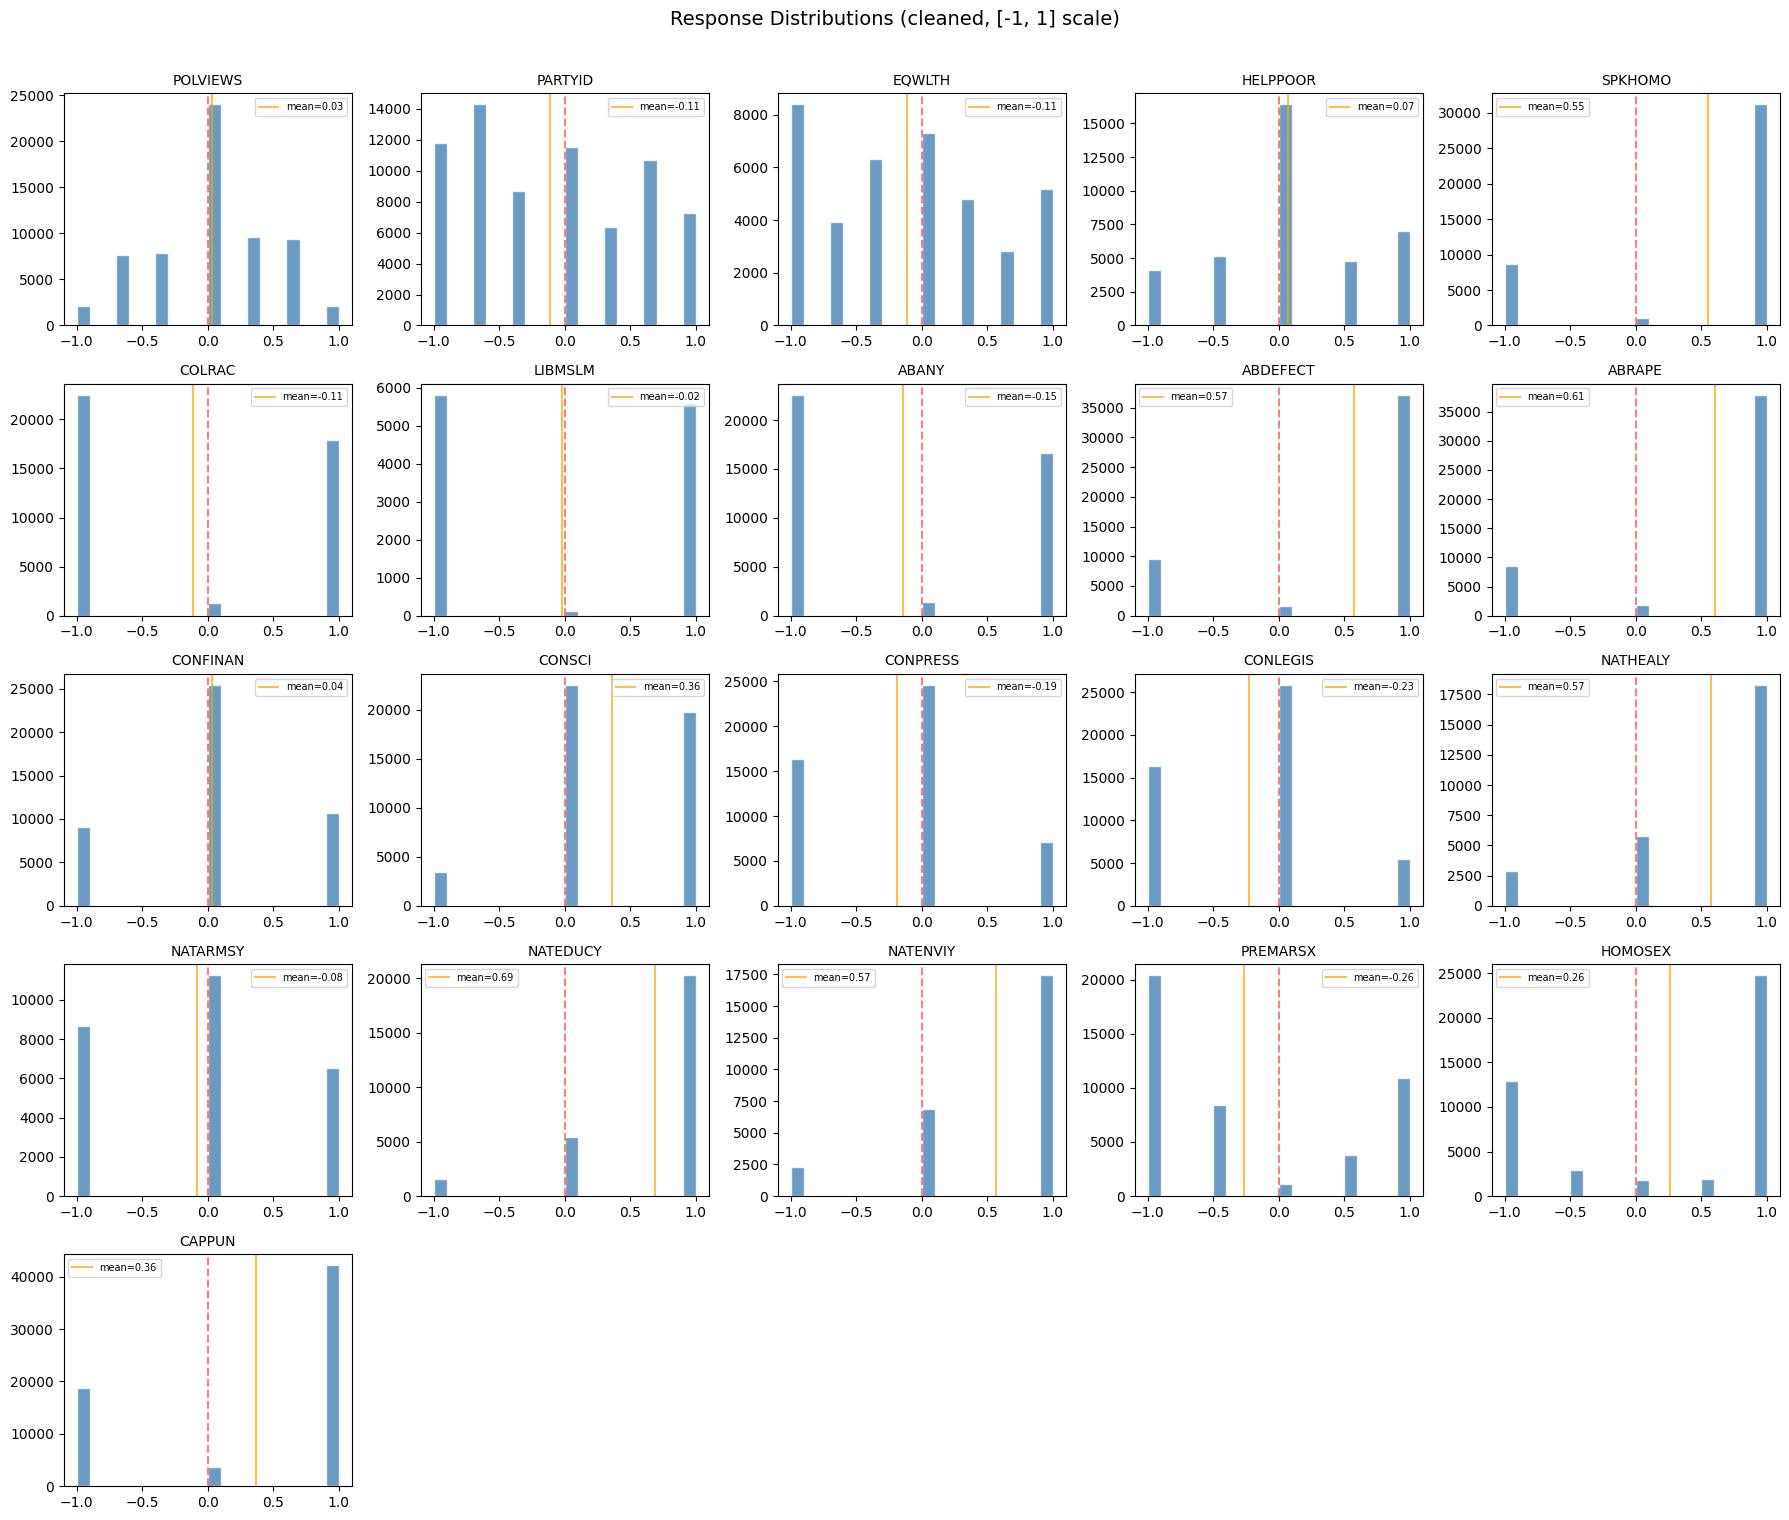

In [10]:
# Select ~20 representative variables across different categories
representative_vars = [
    # Political
    'POLVIEWS', 'PARTYID', 'EQWLTH', 'HELPPOOR',
    # Social tolerance
    'SPKHOMO', 'COLRAC', 'LIBMSLM',
    # Abortion
    'ABANY', 'ABDEFECT', 'ABRAPE',
    # Confidence in institutions
    'CONFINAN', 'CONSCI', 'CONPRESS', 'CONLEGIS',
    # Spending priorities
    'NATHEALY', 'NATARMSY', 'NATEDUCY', 'NATENVIY',
    # Morality
    'PREMARSX', 'HOMOSEX', 'CAPPUN'
]

# Only keep vars that exist in the cleaned data
representative_vars = [v for v in representative_vars if v in cleaned_df.columns]

n_vars = len(representative_vars)
n_cols = 5
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
axes = axes.flatten()

for i, var in enumerate(representative_vars):
    ax = axes[i]
    data = cleaned_df[var].dropna()
    ax.hist(data, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    ax.axvline(x=data.mean(), color='orange', linestyle='-', alpha=0.7, label=f'mean={data.mean():.2f}')
    ax.set_title(var, fontsize=10)
    ax.legend(fontsize=7)
    ax.set_xlim(-1.1, 1.1)

# Hide unused axes
for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Response Distributions (cleaned, [-1, 1] scale)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# Summary: mean and skewness of all belief variables
dist_stats = pd.DataFrame({
    'mean': cleaned_df[belief_vars].mean(),
    'std': cleaned_df[belief_vars].std(),
    'skew': cleaned_df[belief_vars].skew(),
    'n_responses': cleaned_df[belief_vars].notna().sum()
}).sort_values('skew')

print("Most left-skewed variables (negative skew = pile-up at high end):")
print(dist_stats.head(10)[['mean', 'skew', 'n_responses']].to_string())
print()
print("Most right-skewed variables (positive skew = pile-up at low end):")
print(dist_stats.tail(10)[['mean', 'skew', 'n_responses']].to_string())
print()
print(f"Variables with |skew| < 0.5 (roughly symmetric): {(dist_stats['skew'].abs() < 0.5).sum()} of {len(dist_stats)}")

Most left-skewed variables (negative skew = pile-up at high end):
              mean      skew  n_responses
POLATTAK  0.806451 -2.726156        41328
ABHLTH    0.771024 -2.416340        48337
SEXEDUC   0.748302 -2.256183        40775
XMARSEX   0.743969 -2.080358        44602
NATEDUCY  0.685708 -1.667264        27309
ABRAPE    0.608351 -1.530792        48306
TEENSEX   0.600299 -1.434797        32134
ABDEFECT  0.573233 -1.397824        48305
SPKHOMO   0.548667 -1.311913        40952
NATCRIME  0.611284 -1.297187        39242

Most right-skewed variables (positive skew = pile-up at low end):
                                   mean       skew  n_responses
RELIG_Jewish                  -0.960474   6.900870        71953
RELIG_Other                   -0.965978   7.470259        71953
RELIG_Christian               -0.972204   8.304816        71953
RELIG_Buddhism                -0.992440  16.172439        71953
RELIG_Muslim                  -0.994413  18.841251        71953
RELIG_Orthodox_christ

## Summary

See `analyses/2026-02_baseline-data-landscape.md` for the full writeup.